In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [14]:
import pandas as pd

df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [16]:
# Basic statistics
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [17]:
# Check missing values
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [18]:
# Drop missing values
before = len(df)
df = df.dropna()
print(f"Rows removed: {before - len(df)} | Remaining: {len(df)}")

# Remove duplicates
df = df.drop_duplicates()

# Remove tracks with popularity = 0 (unlisted/private)
df = df[df['popularity'] > 0]

# Convert duration from ms to minutes
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

print("✅ Clean dataset:", df.shape)
df.head()

Rows removed: 1 | Remaining: 113999
✅ Clean dataset: (97980, 22)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.84
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.49
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.51
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.37
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.31


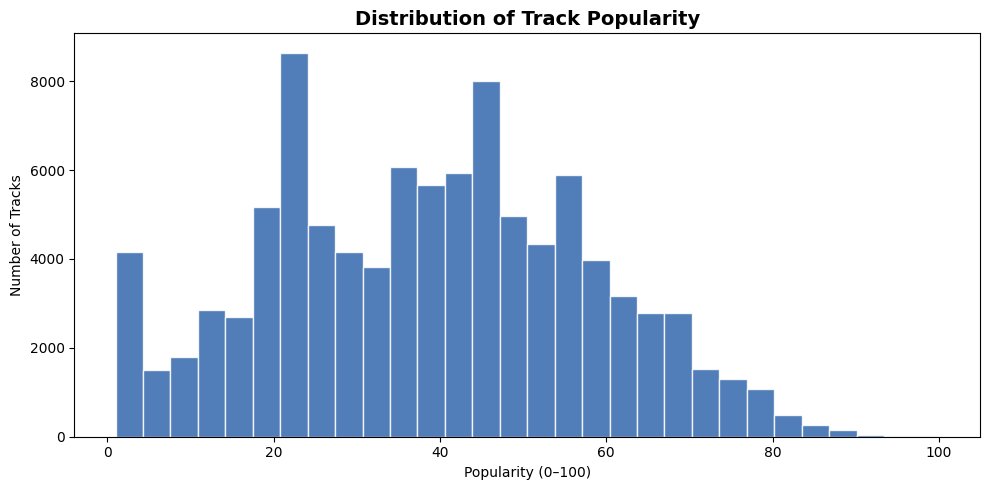

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
plt.hist(df['popularity'], bins=30, color='#3266ad', edgecolor='white', alpha=0.85)
plt.title('Distribution of Track Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.savefig('plot1_distribution.png', dpi=150)
plt.show()

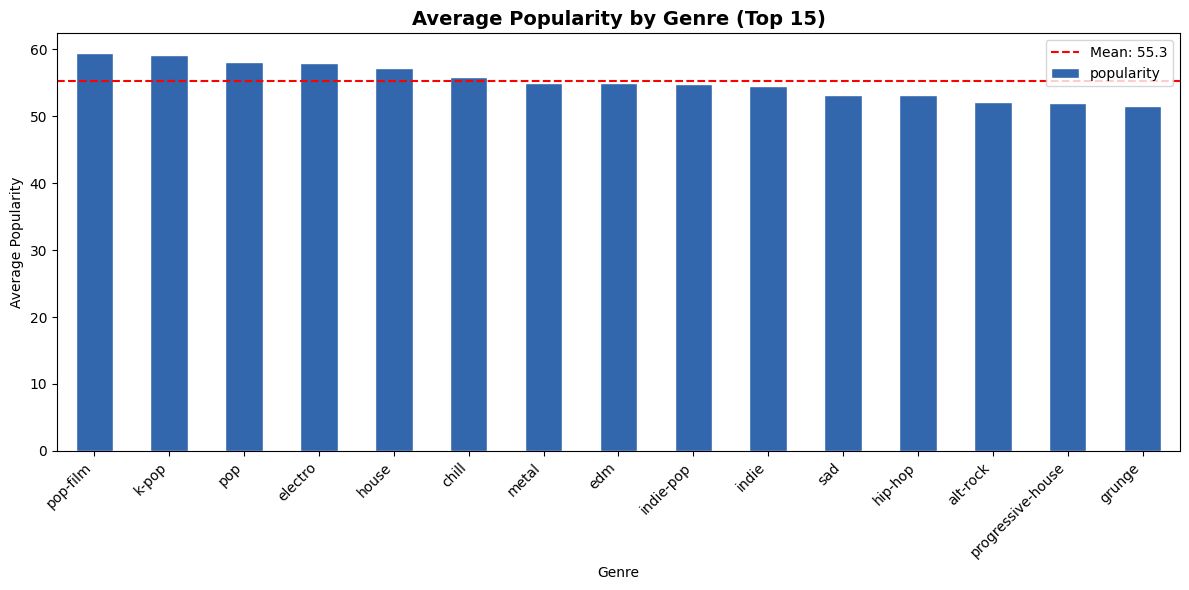

In [20]:
genre_avg = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
genre_avg.plot(kind='bar', color='#3266ad', edgecolor='white')
plt.title('Average Popularity by Genre (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.axhline(genre_avg.mean(), color='red', linestyle='--', label=f'Mean: {genre_avg.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_genre.png', dpi=150)
plt.show()

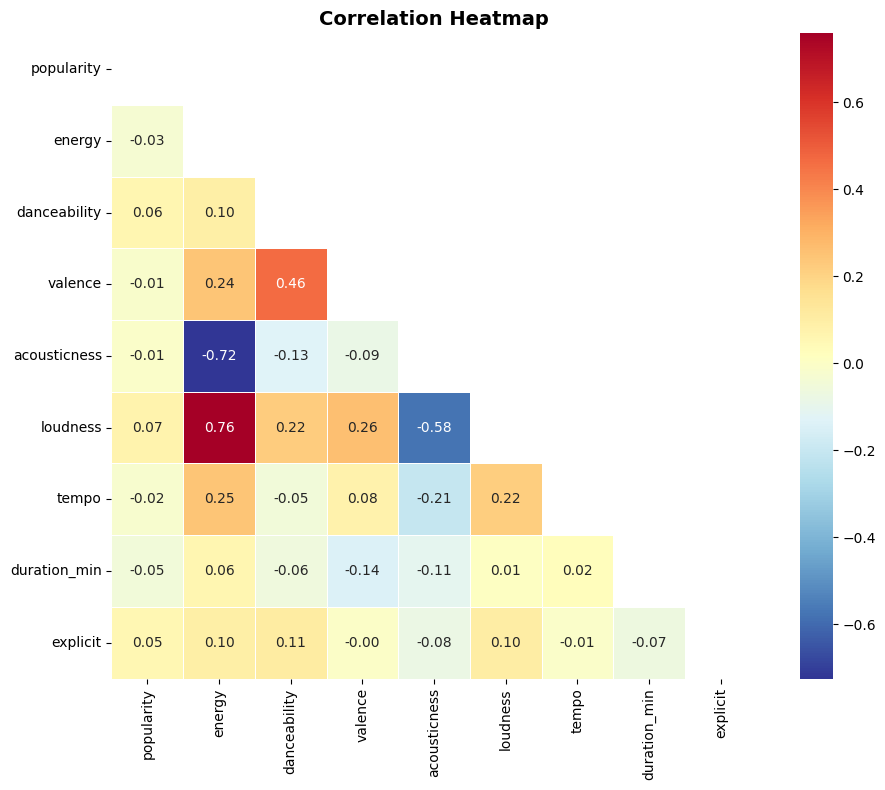

In [21]:
import numpy as np

numeric_cols = ['popularity', 'energy', 'danceability', 'valence',
                'acousticness', 'loudness', 'tempo', 'duration_min', 'explicit']

# Keep only columns that exist in your dataset
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150)
plt.show()

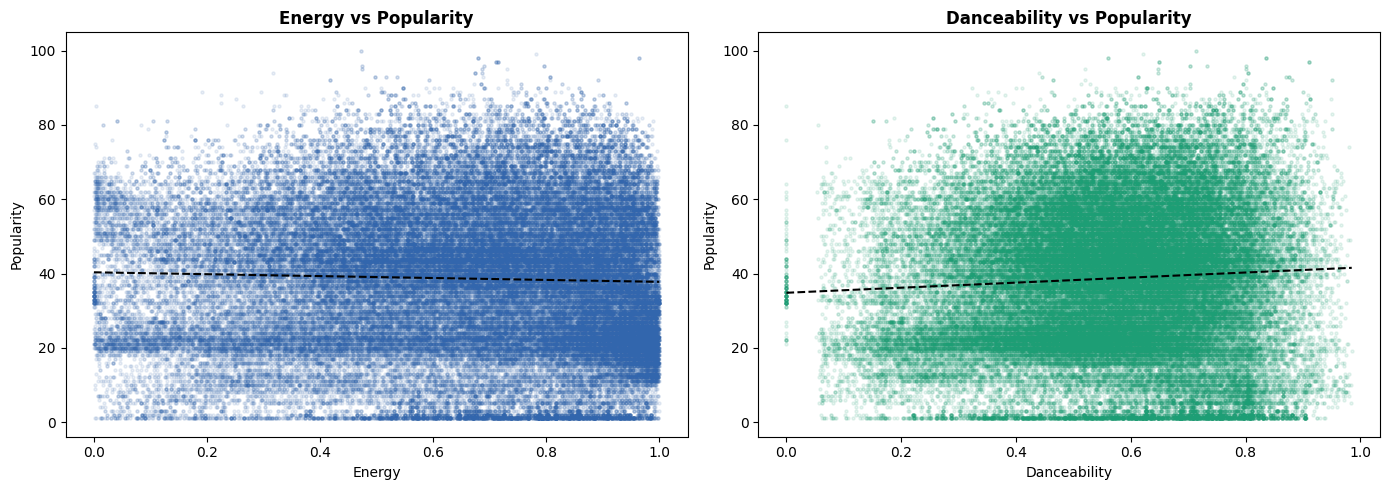

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, col in zip(axes, ['energy', 'danceability'], ['#3266ad', '#1d9e75']):
    ax.scatter(df[feat], df['popularity'], alpha=0.1, s=5, color=col)
    z = np.polyfit(df[feat], df['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5)
    ax.set_xlabel(feat.capitalize())
    ax.set_ylabel('Popularity')
    ax.set_title(f'{feat.capitalize()} vs Popularity', fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_scatter.png', dpi=150)
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

features = ['energy', 'danceability', 'valence', 'acousticness',
            'loudness', 'tempo', 'duration_min', 'explicit', 'genre_encoded']

# Keep only features that exist
features = [f for f in features if f in df.columns]

X = df[features]
y = df['popularity']

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['energy', 'danceability', 'valence', 'acousticness', 'loudness', 'tempo', 'duration_min', 'explicit', 'genre_encoded']
X shape: (97980, 9)
y shape: (97980,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 78384 samples
Test:  19596 samples


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"R² Score : {r2_score(y_test, y_pred_lr):.3f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")

=== Linear Regression ===
R² Score : 0.033
MAE      : 15.63
RMSE     : 19.00


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"R² Score : {r2_score(y_test, y_pred_rf):.3f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

=== Random Forest ===
R² Score : 0.357
MAE      : 11.67
RMSE     : 15.50


In [27]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest'],
    'R² Score': [round(r2_score(y_test, y_pred_lr), 3),
                 round(r2_score(y_test, y_pred_rf), 3)],
    'MAE':      [round(mean_absolute_error(y_test, y_pred_lr), 2),
                 round(mean_absolute_error(y_test, y_pred_rf), 2)],
    'RMSE':     [round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2),
                 round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2)]
})
print(results.to_string(index=False))

            Model  R² Score   MAE  RMSE
Linear Regression     0.033 15.63  19.0
    Random Forest     0.357 11.67  15.5


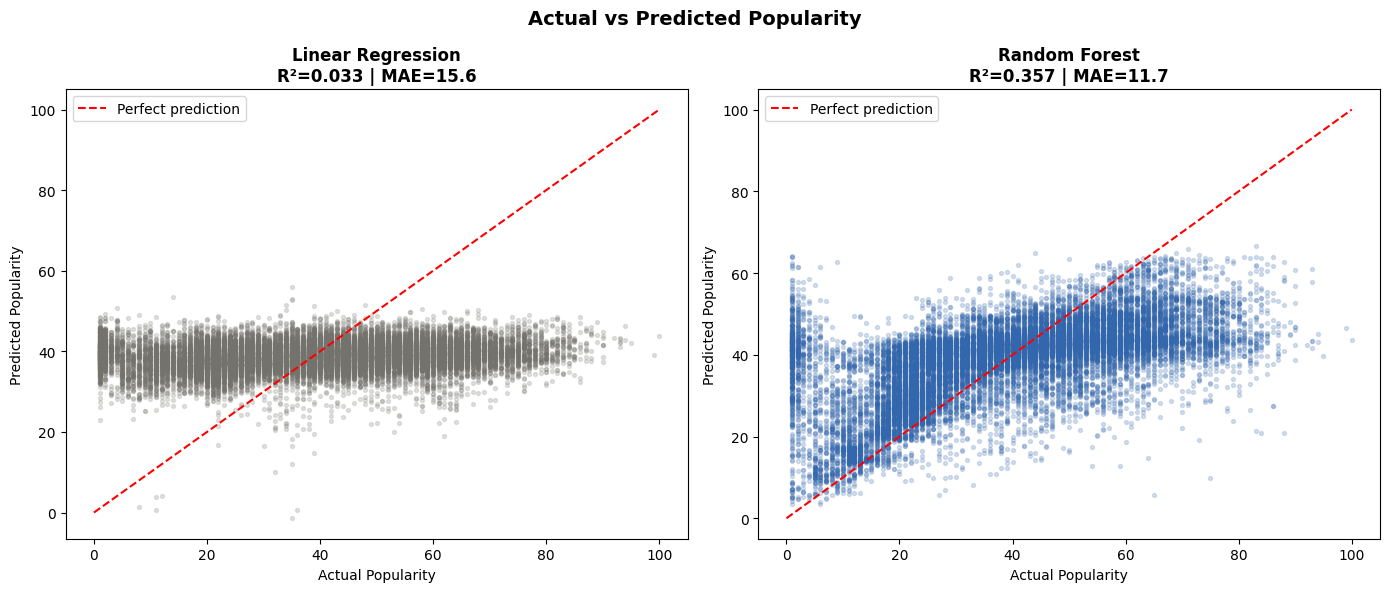

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, col in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['#73726c', '#3266ad']
):
    ax.scatter(y_test, y_pred, alpha=0.2, s=8, color=col)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Popularity')
    ax.set_ylabel('Predicted Popularity')
    ax.set_title(f'{title}\nR²={r2_score(y_test, y_pred):.3f} | MAE={mean_absolute_error(y_test, y_pred):.1f}',
                 fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Popularity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_actual_vs_pred.png', dpi=150)
plt.show()

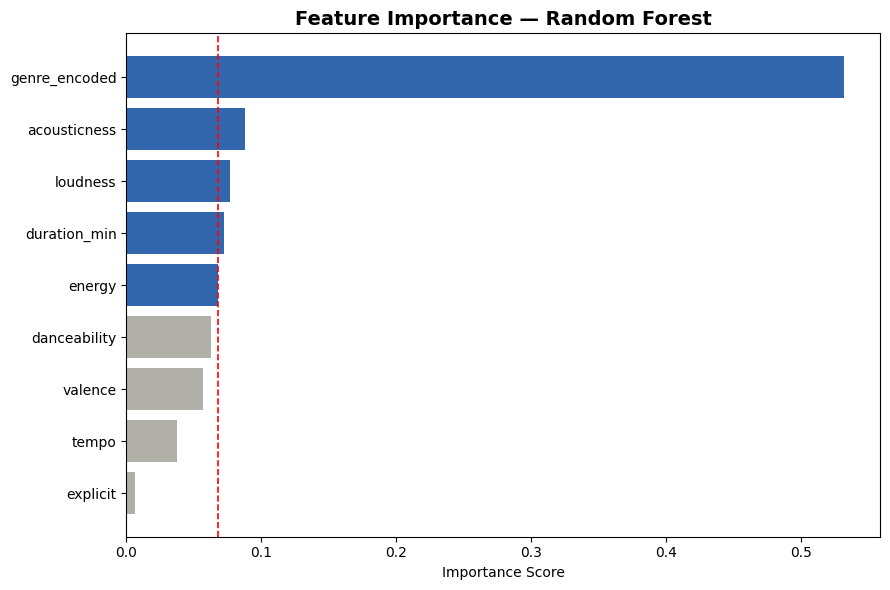

In [29]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#3266ad' if v >= importances.median() else '#b0b0a8' for v in importances.values]
plt.barh(importances.index, importances.values, color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.axvline(importances.median(), color='red', linestyle='--', linewidth=1.2)
plt.tight_layout()
plt.savefig('plot6_feature_importance.png', dpi=150)
plt.show()

In [30]:
# Change these values to test any track!
new_track = pd.DataFrame([{
    'energy':        0.82,
    'danceability':  0.74,
    'valence':       0.65,
    'acousticness':  0.05,
    'loudness':      -5.2,
    'tempo':         128.0,
    'duration_min':  3.2,
    'explicit':      0,
    'genre_encoded': le.transform(['pop'])[0]
}])

pred = rf.predict(new_track)[0]
print(f"🎵 Predicted Popularity: {pred:.1f} / 100")

if pred >= 70:
    print("🔥 Likely a viral hit!")
elif pred >= 50:
    print("📈 Moderate to good reach")
else:
    print("📉 Niche audience")

🎵 Predicted Popularity: 50.2 / 100
📈 Moderate to good reach


In [31]:
from google.colab import files

# Download all saved plots
for fname in ['plot1_distribution.png', 'plot2_genre.png',
              'plot3_heatmap.png', 'plot4_scatter.png',
              'plot5_actual_vs_pred.png', 'plot6_feature_importance.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>